# Text Emotion Detection Using Machine Learning

## 1. Data Understanding

### Project Overview

This project aims to develop a machine learning model capable of detecting emotions from textual data.

The objective is to classify a given text into one of six emotion categories:

- Sadness
- Joy
- Love
- Anger
- Fear
- Surprise

In this notebook, we will load the dataset and perform an initial investigation of its structure, features, target variable, data types, missing values, duplicate records, and class distribution.

In [3]:
from datasets import load_dataset
dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

c:\Users\SINAN P SALIM\OneDrive\Desktop\Project\text-emotion-detection\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SINAN P SALIM\.cache\huggingface\hub\datasets--dair-ai--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

...

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
print(dataset.keys())

dict_keys(['train', 'validation', 'test'])


In [6]:
print("Training samples:", len(dataset["train"]))
print("Validation samples:", len(dataset["validation"]))
print("Test samples:", len(dataset["test"]))

Training samples: 16000
Validation samples: 2000
Test samples: 2000


In [7]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [8]:
dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [10]:
## 1.9 Converting the Dataset to Pandas

import pandas as pd

train_df = dataset["train"].to_pandas()

train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [45]:
train_df.tail()

,text,label,emotion,char_count,word_count
15995,i just had a very brief time in the beanbag an...,0,sadness,101,24
15996,i am now turning and i feel pathetic that i am...,0,sadness,102,20
15997,i feel strong and good overall,1,joy,30,6
15998,i feel like this was such a rude comment and i...,3,anger,59,14
15999,i know a lot but i feel so stupid because i ca...,0,sadness,62,15


In [11]:
train_df.shape

(16000, 2)

In [12]:
train_df.size

32000

In [13]:
train_df.columns

Index(['text', 'label'], dtype='str')

In [14]:
train_df.dtypes

text       str
label    int64
dtype: object

In [15]:
train_df["label"].unique()

array([0, 3, 2, 5, 4, 1])

In [16]:
train_df["label"].value_counts()

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

In [17]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [18]:
train_df.duplicated().sum()

np.int64(1)

In [19]:
train_df[train_df.duplicated(keep=False)]

,text,label
4975,i feel more adventurous willing to take risks ...,1
13846,i feel more adventurous willing to take risks ...,1


In [20]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    16000 non-null  str  
 1   label   16000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.7 MB


In [21]:
train_df.describe()

,label
count,16000.000000
mean,1.565937
std,1.501430
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [ ]:
##  Converting Validation and Test Sets

val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Validation shape: (2000, 2)
Test shape: (2000, 2)


In [46]:
val_df.head()

,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1


In [ ]:
##  Emotion Label Mapping

# The dataset uses numerical labels to represent emotion categories. We will retrieve the corresponding emotion names from the dataset metadata.


label_names = dataset["train"].features["label"].names

print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [25]:
##  Creating the Emotion Column

train_df["emotion"] = train_df["label"].map(
    dict(enumerate(label_names))
)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [26]:
train_df["emotion"].unique()

<ArrowStringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

In [27]:
train_df["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: title={'center': 'Emotion Distribution'}, xlabel='emotion'>

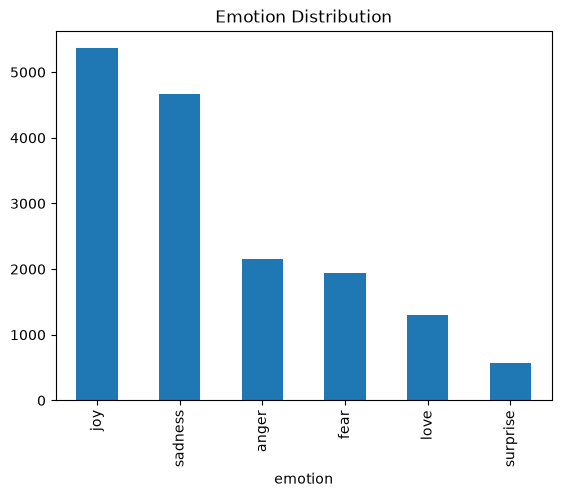

In [28]:
train_df["emotion"].value_counts().plot(
    kind="bar",
    title="Emotion Distribution"
)